In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

WDIR = "/home/daffa/Work/2026/thesis"

df = pd.read_csv(f"{WDIR}/results/ranked_genes_lists/SBC10.multiomics_ranked.tsv", sep="\t")
print(f"Total genes: {len(df):,}")

# Genes with signal in both layers
both = df[(df["variant_score"] > 0) & (df["methylation_score"] > 0)]
print(f"Genes in both layers: {len(both):,}")

Total genes: 20,812
Genes in both layers: 932


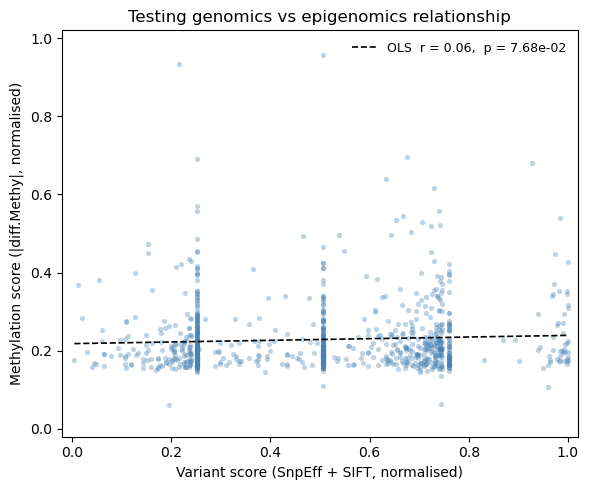

n=932  slope=0.0211  r=0.0580  p=7.6761e-02


In [4]:
x = both["variant_score"].values
y = both["methylation_score"].values
slope, intercept, r, p, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(x, y, color="steelblue", s=14, alpha=0.35, linewidths=0)

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(
    x_line, slope * x_line + intercept,
    color="black", linewidth=1.2, linestyle="--",
    label=f"OLS  r = {r:.2f},  p = {p:.2e}",
)

ax.set_xlabel("Variant score (SnpEff + SIFT, normalised)")
ax.set_ylabel("Methylation score (|diff.Methy|, normalised)")
ax.set_title("Testing genomics vs epigenomics relationship")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(f"{WDIR}/analysis/figures/epi_genomics_cooccurrence_SBC10.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"n={len(both):,}  slope={slope:.4f}  r={r:.4f}  p={p:.4e}")